# Binary classification with a Perceptron

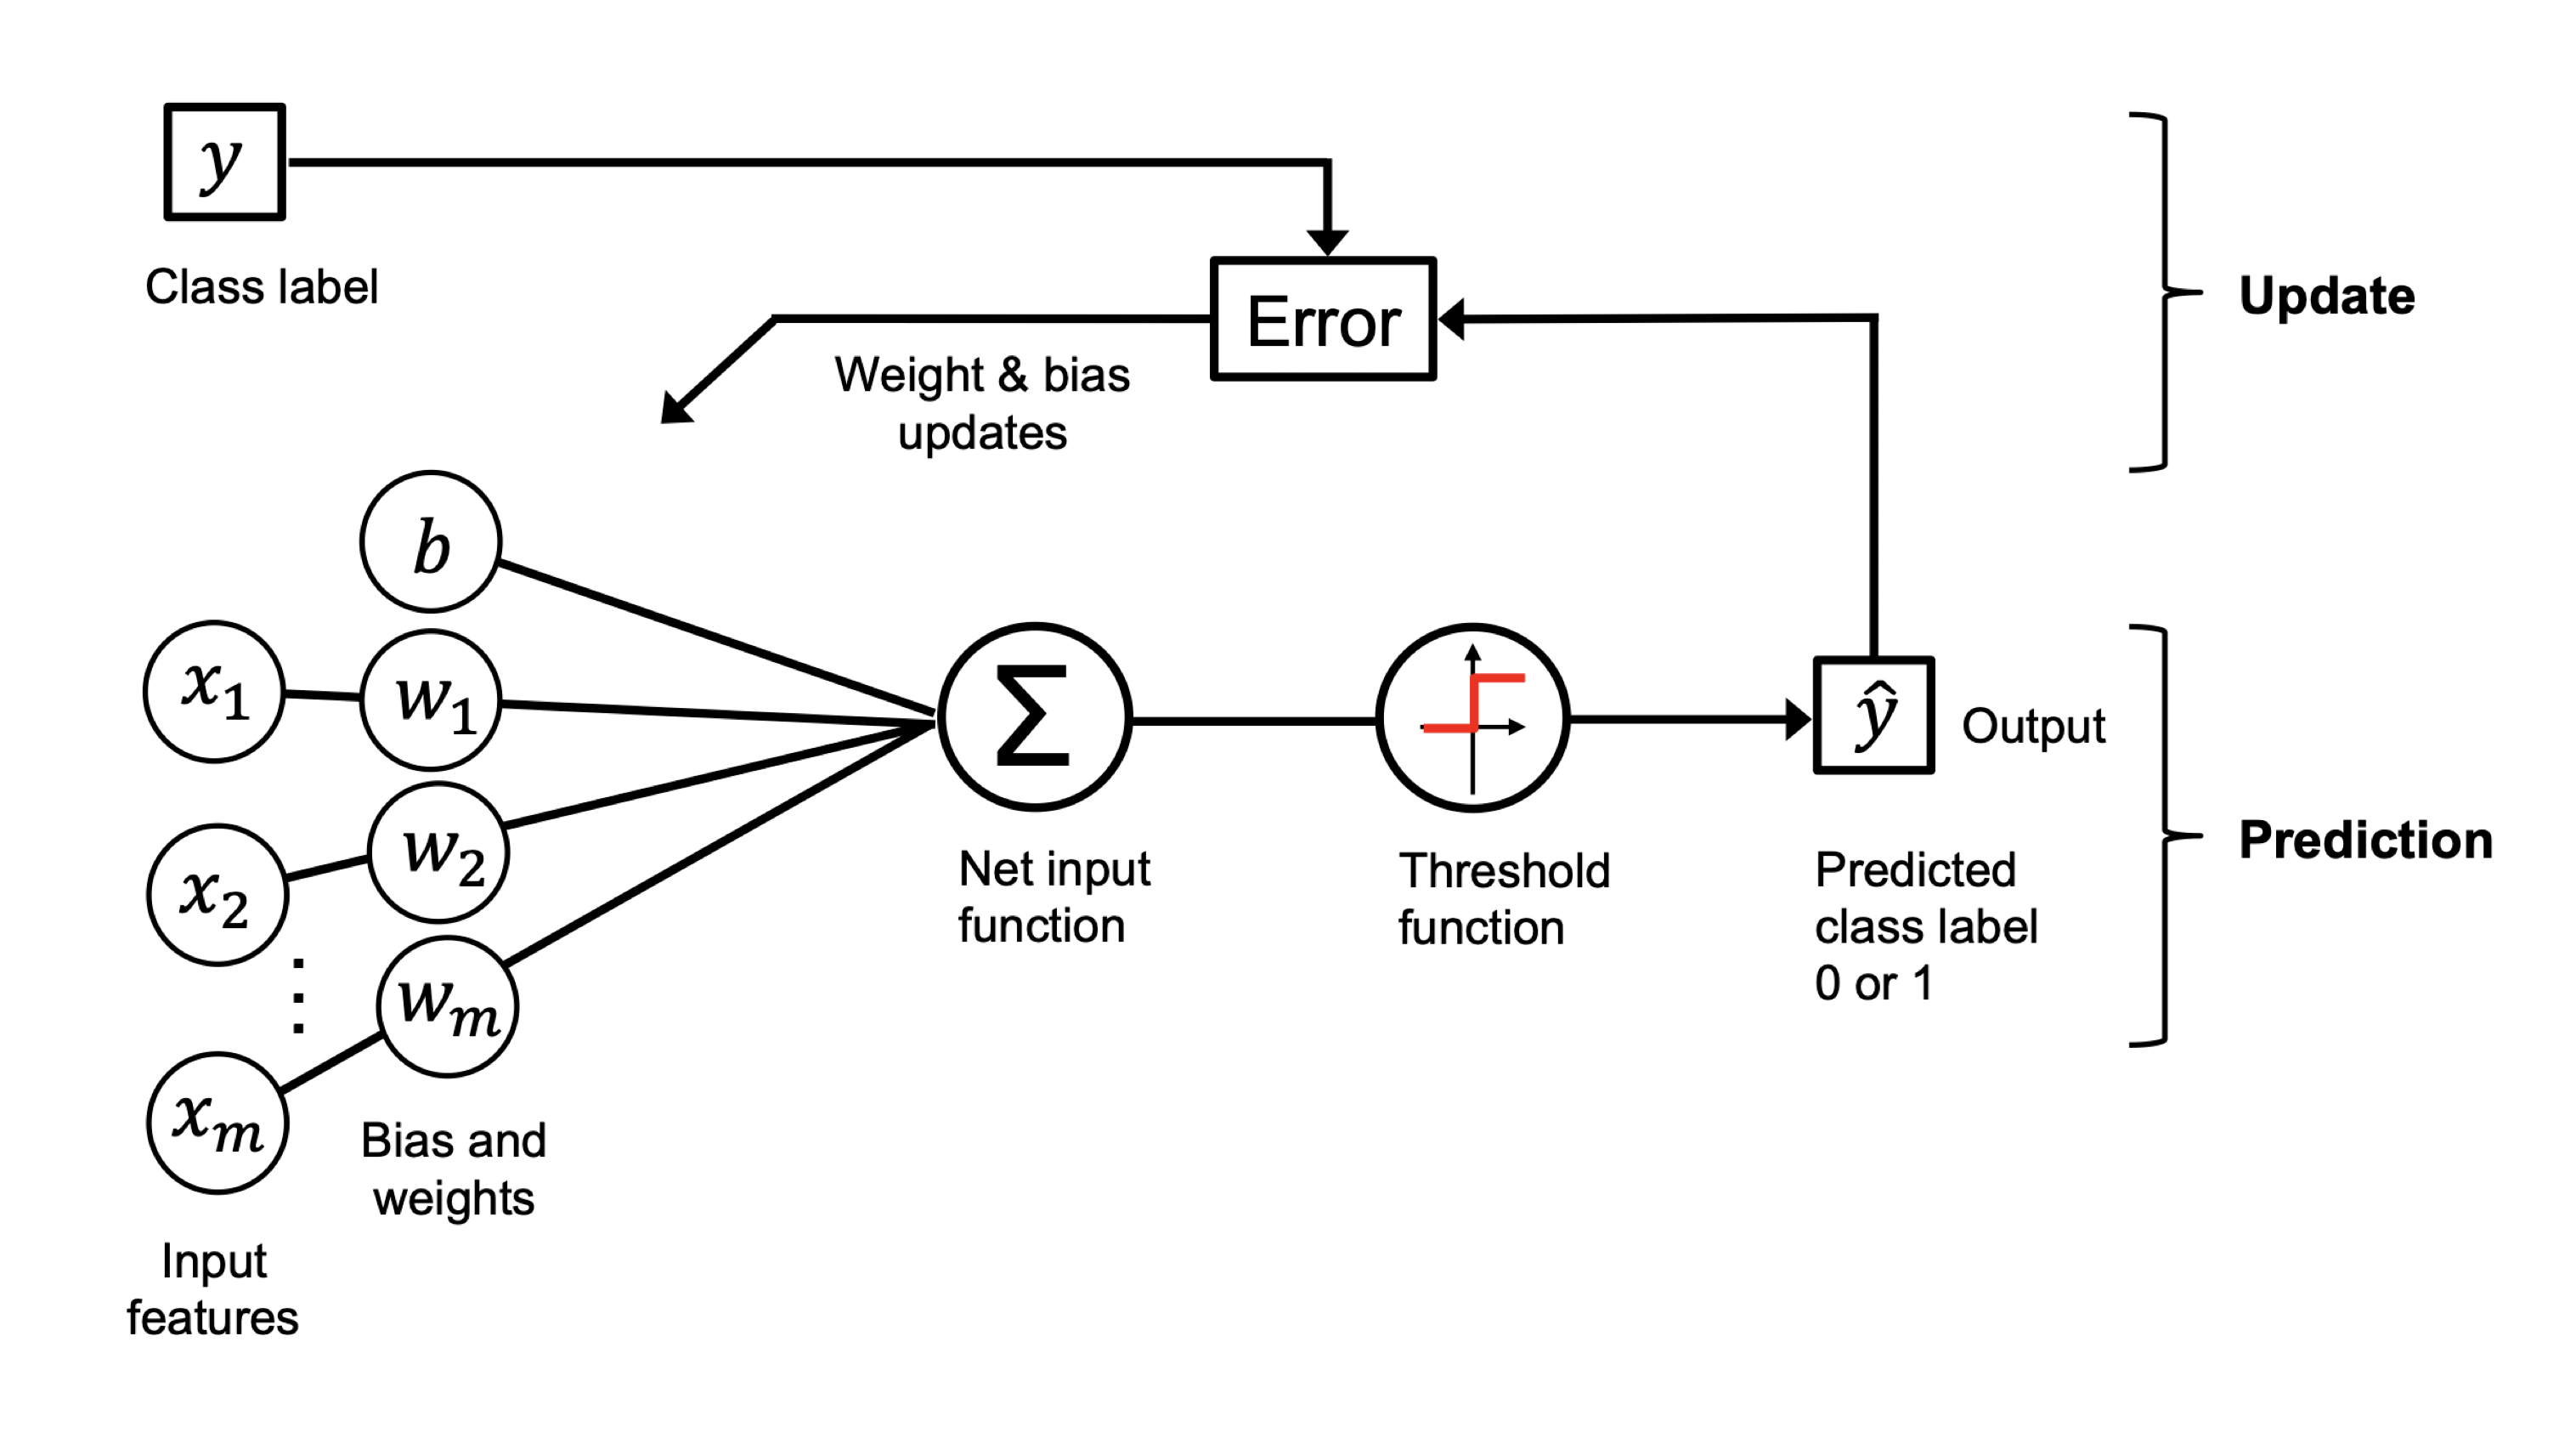

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

## Step 0 - Get the Iris dataset

In [2]:
import pandas as pd
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
                 header=None, encoding='utf-8')
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


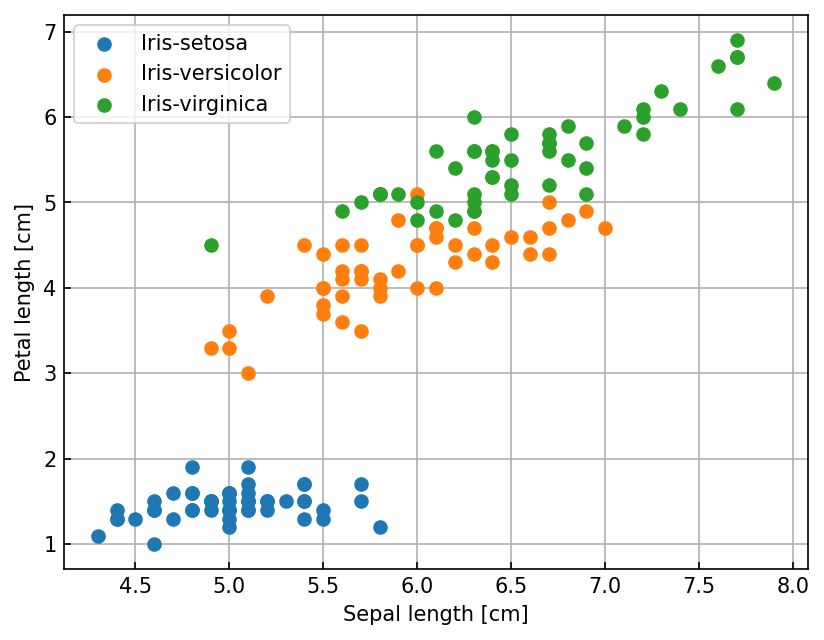

In [3]:
ax = plt.figure().gca()

labels = df[4].unique()
for label in labels:
    mask = df[4] == label
    ax.scatter(df.loc[mask, 0], df.loc[mask, 2], label=label)
    
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')
ax.legend();

We're going to focus on binary classification, so let's pick two of these classes to distinguish.

Fitting a dataset with X: (100, 2) and y: (100,)
There are 50 examples of Iris-versicolor


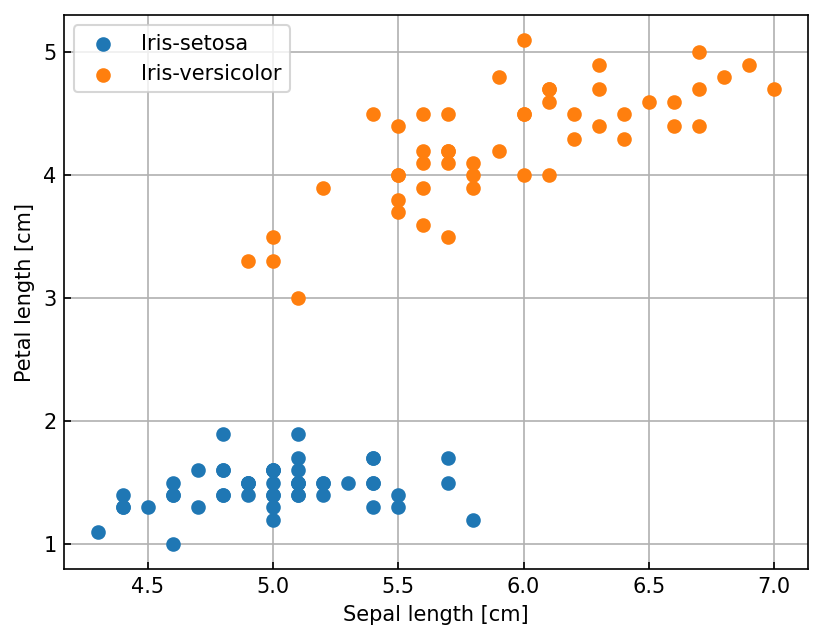

In [4]:
mask = df[4] != 'Iris-virginica'

X = df.loc[mask, [0, 2]].values
y = df.loc[mask, 4].values
print(f"Fitting a dataset with X: {X.shape} and y: {y.shape}")

# Encode the dataset labels from strings to numbers
y_enc = np.zeros(y.shape)
y_enc[y == 'Iris-versicolor'] = 1
print(f'There are {int(y_enc.sum())} examples of Iris-versicolor')

labels = np.unique(y)
ax = plt.figure().gca()
for label in labels:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=label)

ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')
ax.legend();

## Step 1 - Define and fit Perceptron class

We're going to follow the sklearn-ish protocol of having a `fit` and `predict` function. There are advantages and disadvantages to this for deep learning but we won't get into that right now. 

In [5]:
class Perceptron:
    """ Parameters:
        -----------
        alpha : float - Learning rate between 0 and 1
        num_epochs : int - Iterations over the training data
        random_seed : int - Random seed

        Attributes:
        -----------
        w_ : 1d array of weights
        b_ : bias term
        num_errors : number of misclassifications each epoch
    """
    def __init__(self, alpha=0.01, num_epochs=20, random_seed=42):
        self.alpha = alpha
        self.num_epochs = num_epochs
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples,]
        """
        np.random.seed(self.random_seed)
        self.w_ = np.random.normal(size=X.shape[1])
        self.b_ = np.float32(0.)

        self.num_errors = []

        # iterate over epochs
        for _ in range(self.num_epochs):
            n_errors = 0
            # iterate over data
            for xi, yi in zip(X, y):
                diff = yi - self.predict(xi)
                self.w_ += self.alpha * diff * xi
                self.b_ += self.alpha * diff

                n_errors += int(diff != 0.)

            self.num_errors.append(n_errors)

        return self

    def predict(self, X):
        z = np.dot(X, self.w_) + self.b_
        return np.where(z >= 0., 1, 0)

In [6]:
model = Perceptron()
model.fit(X, y_enc)

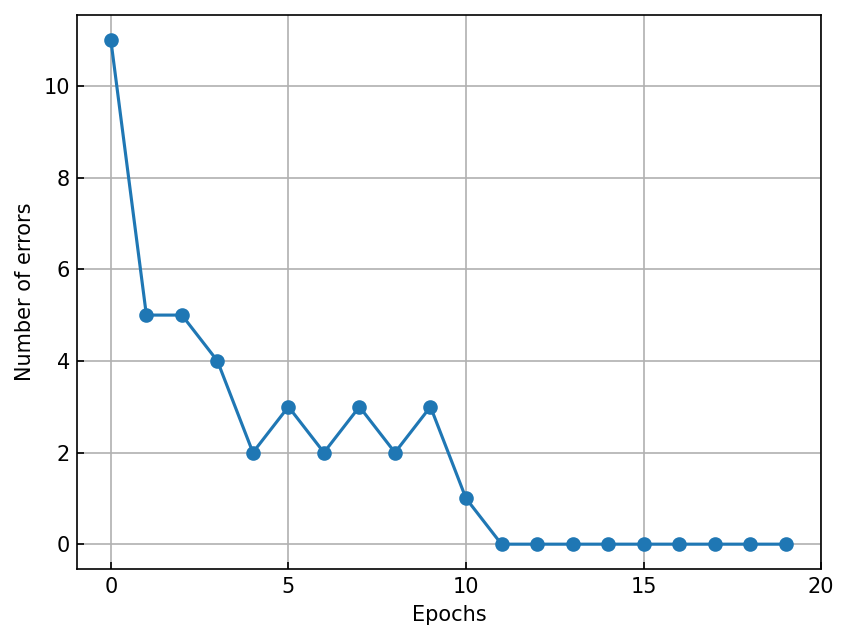

In [7]:
ax = plt.figure().gca()
ax.plot(model.num_errors, marker='o')
ax.set(xlabel='Epochs', xticks=[0, 5, 10, 15, 20],
       ylabel='Number of errors');

## Step 2 - Plot decision boundary

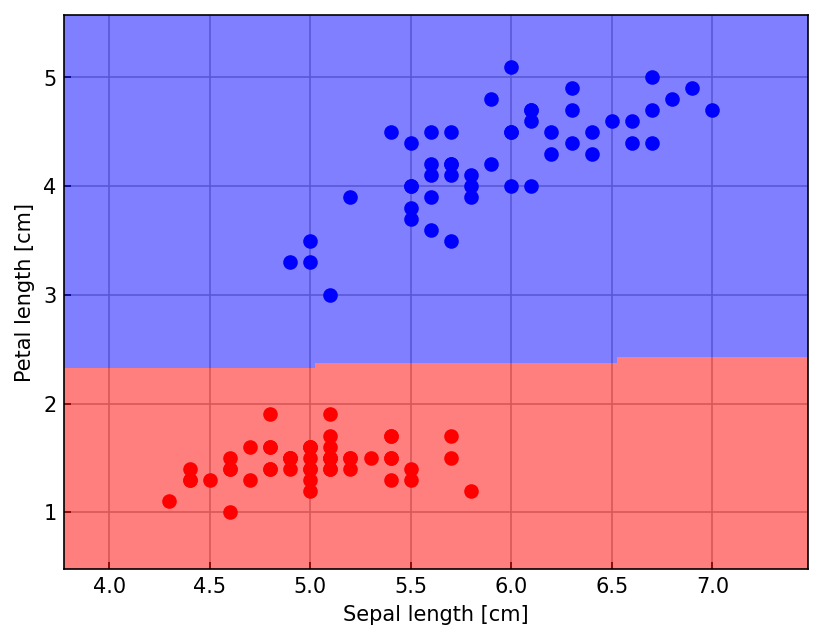

In [8]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.05, colors=['red', 'blue']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min() - 10*d, X[:, 0].max() + 10*d, d),
        np.arange(X[:, 1].min() - 10*d, X[:, 1].max() + 10*d, d),
    )
    y_grid = model.predict(np.stack([x1.ravel(), x2.ravel()]).T) # [N, 2]
    y_grid = y_grid.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im = ax.pcolormesh(x1, x2, y_grid, cmap=cmap, alpha=0.5)

    for ii, label in enumerate(np.unique(y)):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[int(label)])
        
ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_enc, model)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]');

If I am **ultra** careful about scaling units correctly, I can see that the weight vector of the model is perpendicular to the decision boundary!

Text(6.0, 2.35, '')

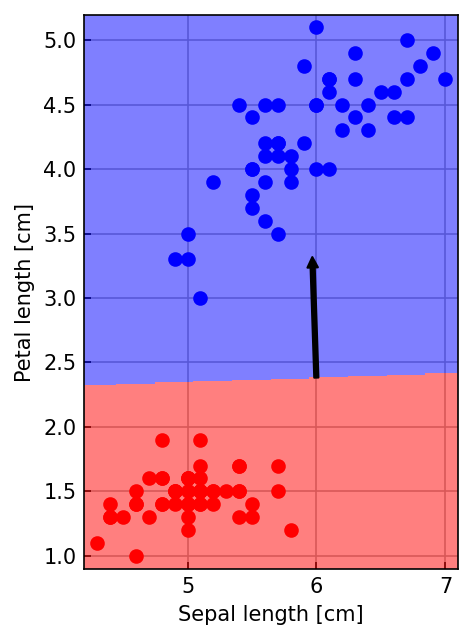

In [9]:
ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_enc, model, d=0.01)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]', aspect='equal')

w_norm = model.w_ / np.linalg.norm(model.w_)
ax.annotate(
    "",
    xytext=(6.0, 2.35),
    xy=(6.0 + w_norm[0], 2.35 + w_norm[1]),
    arrowprops=dict(arrowstyle='simple', lw=1, color='black'),
)

### We can look at what the decision boundary was before fitting too!

It's not very interesting

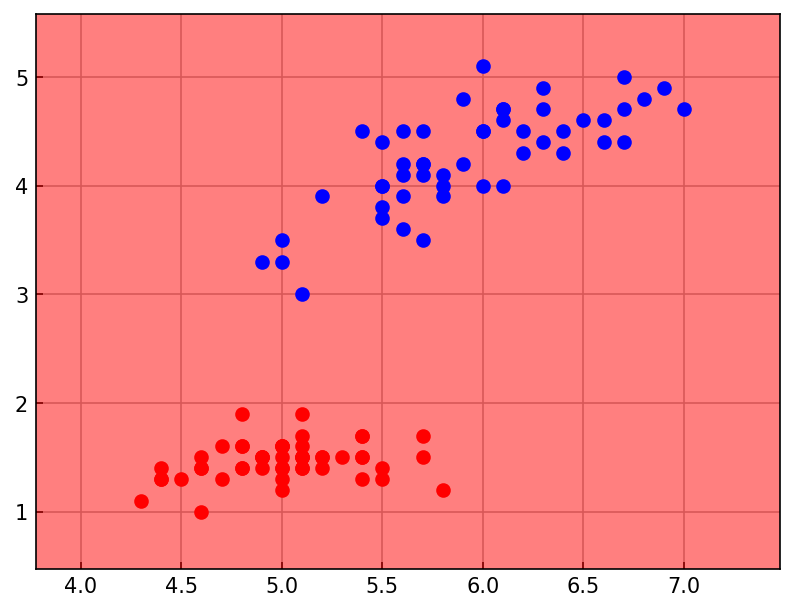

In [10]:
ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_enc, Perceptron(num_epochs=0).fit(X, y_enc))